In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle

In [2]:
overall_df = pd.read_csv("2016_to_2023_full_preprocessed_data_set.csv")

In [3]:
overall_df["VolAny"] = overall_df["VolAny"].fillna(0)

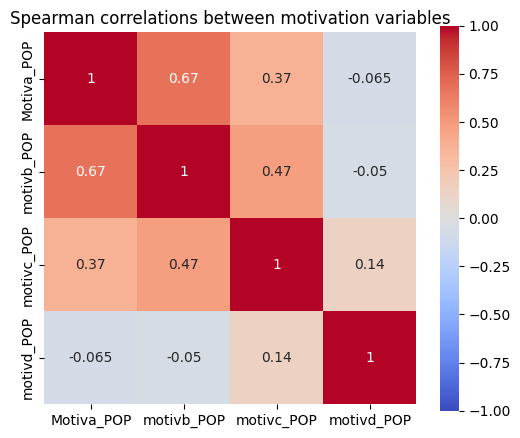

In [4]:
motivation_cols = ["Motiva_POP", "motivb_POP", "motivc_POP", "motivd_POP"]

corr = overall_df[motivation_cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)

plt.title("Spearman correlations between motivation variables")
plt.show()

In [5]:
motivation_cols = ["Motiva_POP", "motivb_POP", "motivc_POP"]

motivation_df = overall_df[motivation_cols].dropna().copy()

scaler = StandardScaler()
motivation_scaled = scaler.fit_transform(motivation_df)

pca = PCA(n_components=1)
pc1 = pca.fit_transform(motivation_scaled).flatten()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.3f} of the variance")

motivation_df["Motivation_PC"] = pc1

overall_df = overall_df.merge(motivation_df[["Motivation_PC"]], left_index=True, right_index=True, how="left")

PC1 explains 0.666 of the variance


In [6]:
loadings = pd.DataFrame(pca.components_.T, index=motivation_cols, columns=["Loading"])

print(loadings)

             Loading
Motiva_POP  0.588287
motivb_POP  0.625731
motivc_POP  0.512229


In [7]:
input_cols = ["Age9",
              "Gend3",
              "Eth7",
              "Disab3",
              "NSSEC5",
              "Educ6",
              "Child4",
              "IMD10",
              "WorkStat5",
              "VolAny",
              "Motivation_PC"]
  
cluster_df = overall_df[input_cols + ["year"]].dropna().copy()

cluster_df["Motivation_PC_Q"] = (pd.qcut(cluster_df["Motivation_PC"], q=5, labels=False).astype(int))

cluster_df = cluster_df.drop(columns="Motivation_PC")

In [8]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab3",
                "NSSEC5",
                "Educ6",
                "Child4",
                "IMD10",
                "WorkStat5",
                "VolAny",
                "Motivation_PC_Q"]

for col in cluster_cols:
    print(cluster_df[col].value_counts(dropna=False))

Age9
4.0    19999
3.0    18402
5.0    16143
6.0    13887
7.0    10762
2.0     7485
8.0      537
9.0      139
Name: count, dtype: int64
Gend3
2.0    48776
1.0    38390
3.0      188
Name: count, dtype: int64
Eth7
1.0    46463
2.0    15340
3.0    12392
4.0     5583
6.0     3075
7.0     2456
5.0     2045
Name: count, dtype: int64
Disab3
3.0    63776
2.0    12961
1.0    10617
Name: count, dtype: int64
NSSEC5
1.0    57604
2.0    15588
3.0     7339
4.0     6147
5.0      676
Name: count, dtype: int64
Educ6
1.0    61300
2.0     9705
3.0     9305
6.0     3275
5.0     2709
4.0     1060
Name: count, dtype: int64
Child4
1.0    60325
2.0    12962
3.0    10878
4.0     3189
Name: count, dtype: int64
IMD10
2.0     13952
3.0     12916
4.0     10877
5.0      9705
6.0      8852
7.0      7511
9.0      7211
8.0      6877
1.0      5602
10.0     3851
Name: count, dtype: int64
WorkStat5
1.0    59955
3.0    16291
4.0     4993
2.0     3706
5.0     2409
Name: count, dtype: int64
VolAny
0.0    75559
1.0    11795
N

In [9]:
len(cluster_df)

87354

In [10]:
X = cluster_df[cluster_cols].copy().astype(int)

for col in X.columns:
    X[col] = X[col] - X[col].min()
    
X.head()

,Age9,Gend3,Eth7,Disab3,NSSEC5,Educ6,Child4,IMD10,WorkStat5,VolAny,Motivation_PC_Q
0,0,0,3,2,0,0,1,1,0,1,1
1,2,0,3,2,1,0,0,3,0,0,3
2,2,1,0,2,0,0,0,6,0,0,2
3,2,0,1,2,0,0,1,3,0,0,4
4,2,1,1,0,0,0,1,3,0,0,0


In [11]:
results = []

for k in [19, 20, 21, 22, 23, 24, 25]:

    try:
    
        print(f"Fitting {k} classes...")

        model = StepMix(n_components=k,  measurement="categorical", random_state=42, n_init=50, max_iter=5000, abs_tol=1e-5)

        model.fit(X)

        with open(f"stepmix_new_{k}.pkl", "wb") as f:
             pickle.dump(model, f)

        posterior = model.predict_proba(X)
        predicted = model.predict(X)

        proportions = posterior.mean(axis=0)
        assignment = posterior.max(axis=1)

        loglik = model.score(X) * len(X)

        print(f"Log-likelihood : {loglik:,.2f}")
        print(f"AIC            : {model.aic(X):,.2f}")
        print(f"BIC            : {model.bic(X):,.2f}")
        print(f"Converged      : {model.converged_}")
        print(f"Iterations     : {model.n_iter_}")

        print("\nClass proportions")
        print(pd.Series(proportions).round(4))

        print("\nObserved class sizes")
        print(pd.Series(predicted).value_counts(normalize=True).sort_index().round(4))

        print("\nPosterior assignment certainty")
        print(pd.Series(assignment).describe())

        print(f"\nMean assignment probability : {assignment.mean():.4f}")
        print(f"Median assignment           : {np.median(assignment):.4f}")
        print(f"Minimum assignment          : {assignment.min():.4f}")

        temp = cluster_df.copy()
        temp["Class"] = predicted

        print("\nYear by latent class")
        print(pd.crosstab(temp["year"], temp["Class"], normalize="index").round(3))

        print("\nModel attributes")
        print(sorted(model.__dict__.keys()))

        params = model.get_parameters()

        print("\nParameter keys:")
        print(params.keys())

        measurement = params["measurement"]

        print("\nMeasurement parameters")
        print(type(measurement))

        if isinstance(measurement, dict):
            print("Measurement keys:")
            print(measurement.keys())

            for key, value in measurement.items():
                print(f"\n{key}")
                print(type(value))
                if hasattr(value, "shape"):
                    print("Shape:", value.shape)
        else:
            if hasattr(measurement, "shape"):
                print("Shape:", measurement.shape)
            else:
                print(measurement)

        results.append({"Classes": k,
                        "LogLik": loglik,
                        "AIC": model.aic(X),
                        "BIC": model.bic(X),
                        "Converged": model.converged_,
                        "Iterations": model.n_iter_,
                        "MeanAssignment": assignment.mean(),
                        "MedianAssignment": np.median(assignment),
                        "MinClass": proportions.min(),
                        "MaxClass": proportions.max(),
                        "EffectiveClasses": (proportions > 0.01).sum()})
        
    except Exception as e:
        results.append({"Classes": k, "Error": str(e)})

    pd.DataFrame(results).to_csv("stepmix_new_latent_class_analysis_results.csv", index=False)

Fitting 19 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 50/50 [31:54<00:00, 38.29s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Log-likelihood : -1,029,844.16
AIC            : 2,061,510.32
BIC            : 2,070,053.42
Converged      : True
Iterations     : 159

Class proportions
0     0.0340
1     0.0201
2     0.0536
3     0.0077
4     0.0446
5     0.0319
6     0.0659
7     0.1194
8     0.0441
9     0.0355
10    0.0268
11    0.0284
12    0.0229
13    0.0960
14    0.0391
15    0.0194
16    0.0721
17    0.0600
18    0.1785
dtype: float64

Observed class sizes
0     0.0317
1     0.0201
2     0.0443
3     0.0077
4     0.0435
5     0.0337
6     0.0562
7     0.1346
8     0.0394
9     0.0358
10    0.0220
11    0.0310
12    0.0215
13    0.0970
14    0.0365
15    0.0171
16    0.0576
17    0.0718
18    0.1985
Name: proportion, dtype: float64

Posterior assignment certainty
count    87354.000000
mean         0.727174
std          0.192515
min          0.175045
25%          0.569858
50%          0.738351
75%          0.911176
max          1.000000
dtype: float64

Mean assignment probability : 0.7272
Median assignment     

Initializations (n_init) : 100%|██████████| 50/50 [36:26<00:00, 43.72s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Log-likelihood : -1,029,360.97
AIC            : 2,060,639.93
BIC            : 2,069,633.17
Converged      : True
Iterations     : 321

Class proportions
0     0.0340
1     0.0737
2     0.0355
3     0.1245
4     0.0258
5     0.1012
6     0.0200
7     0.0309
8     0.0223
9     0.0390
10    0.0952
11    0.0837
12    0.0886
13    0.0434
14    0.0323
15    0.0077
16    0.0202
17    0.0193
18    0.0350
19    0.0678
dtype: float64

Observed class sizes
0     0.0337
1     0.0894
2     0.0358
3     0.1319
4     0.0249
5     0.1006
6     0.0201
7     0.0234
8     0.0201
9     0.0352
10    0.0917
11    0.0709
12    0.0970
13    0.0451
14    0.0334
15    0.0077
16    0.0191
17    0.0180
18    0.0344
19    0.0676
Name: proportion, dtype: float64

Posterior assignment certainty
count    87354.000000
mean         0.696726
std          0.194799
min          0.147121
25%          0.531618
50%          0.705071
75%          0.867616
max          1.000000
dtype: float64

Mean assignment probability : 0.6

...

Log-likelihood : -1,028,500.93
AIC            : 2,059,207.86
BIC            : 2,069,551.49
Converged      : True
Iterations     : 201

Class proportions
0     0.0202
1     0.0417
2     0.0277
3     0.0523
4     0.0205
5     0.0496
6     0.0917
7     0.0659
8     0.0552
9     0.0735
10    0.0342
11    0.0300
12    0.0334
13    0.0171
14    0.0355
15    0.0211
16    0.0704
17    0.0200
18    0.0077
19    0.0866
20    0.0580
21    0.0647
22    0.0228
dtype: float64

Observed class sizes
0     0.0170
1     0.0428
2     0.0319
3     0.0499
4     0.0195
5     0.0423
6     0.1054
7     0.0650
8     0.0694
9     0.0651
10    0.0336
11    0.0313
12    0.0306
13    0.0161
14    0.0358
15    0.0195
16    0.0742
17    0.0200
18    0.0077
19    0.0827
20    0.0476
21    0.0712
22    0.0215
Name: proportion, dtype: float64

Posterior assignment certainty
count    87354.000000
mean         0.658090
std          0.192431
min          0.168624
25%          0.503439
50%          0.641622
75%          0.

Initializations (n_init) : 100%|██████████| 50/50 [40:34<00:00, 48.68s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Log-likelihood : -1,028,300.74
AIC            : 2,058,903.48
BIC            : 2,069,697.24
Converged      : True
Iterations     : 178

Class proportions
0     0.0788
1     0.0571
2     0.0182
3     0.0827
4     0.0136
5     0.0623
6     0.0309
7     0.0350
8     0.0231
9     0.0199
10    0.0077
11    0.0279
12    0.0787
13    0.0352
14    0.0647
15    0.0232
16    0.0267
17    0.0214
18    0.0588
19    0.0222
20    0.0428
21    0.0280
22    0.0509
23    0.0899
dtype: float64

Observed class sizes
0     0.0854
1     0.0589
2     0.0180
3     0.0916
4     0.0115
5     0.0599
6     0.0282
7     0.0356
8     0.0152
9     0.0200
10    0.0077
11    0.0317
12    0.0839
13    0.0356
14    0.0581
15    0.0245
16    0.0243
17    0.0202
18    0.0698
19    0.0214
20    0.0431
21    0.0212
22    0.0430
23    0.0910
Name: proportion, dtype: float64

Posterior assignment certainty
count    87354.000000
mean         0.666229
std          0.195381
min          0.178338
25%          0.505698
50%        

Initializations (n_init) : 100%|██████████| 50/50 [1:35:33<00:00, 114.67s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Log-likelihood : -1,027,926.98
AIC            : 2,058,251.96
BIC            : 2,069,495.85
Converged      : True
Iterations     : 350

Class proportions
0     0.0879
1     0.0734
2     0.0235
3     0.0836
4     0.0400
5     0.0188
6     0.0315
7     0.0327
8     0.0199
9     0.0355
10    0.0266
11    0.0110
12    0.0474
13    0.0188
14    0.0305
15    0.0202
16    0.0537
17    0.0077
18    0.0561
19    0.0726
20    0.0717
21    0.0786
22    0.0272
23    0.0151
24    0.0158
dtype: float64

Observed class sizes
0     0.0855
1     0.0789
2     0.0214
3     0.0854
4     0.0405
5     0.0164
6     0.0292
7     0.0321
8     0.0200
9     0.0359
10    0.0233
11    0.0107
12    0.0435
13    0.0174
14    0.0314
15    0.0192
16    0.0606
17    0.0077
18    0.0524
19    0.0774
20    0.0646
21    0.0866
22    0.0316
23    0.0133
24    0.0150
Name: proportion, dtype: float64

Posterior assignment certainty
count    87354.000000
mean         0.657941
std          0.205459
min          0.117144
25%    

In [12]:
results_df = pd.DataFrame(results)

print(results_df)

   Classes        LogLik           AIC           BIC  Converged  Iterations  \
0       19 -1.029844e+06  2.061510e+06  2.070053e+06       True         159   
1       20 -1.029361e+06  2.060640e+06  2.069633e+06       True         321   
2       21 -1.028998e+06  2.060011e+06  2.069454e+06       True         332   
3       22 -1.028684e+06  2.059477e+06  2.069371e+06       True         458   
4       23 -1.028501e+06  2.059208e+06  2.069551e+06       True         201   
5       24 -1.028301e+06  2.058903e+06  2.069697e+06       True         178   
6       25 -1.027927e+06  2.058252e+06  2.069496e+06       True         350   

   MeanAssignment  MedianAssignment  MinClass  MaxClass  EffectiveClasses  
0        0.727174          0.738351  0.007739  0.178463                18  
1        0.696726          0.705071  0.007739  0.124460                19  
2        0.686644          0.680228  0.007739  0.129478                20  
3        0.675234          0.670751  0.007739  0.101199        